# Breast Ultrasound Image Classification
## Depthwise Separable CNN · Class Weights · SMOTE

**DLMI Project**

This project classifies breast ultrasound images into **benign**, **malignant**, and **normal** using a CNN with **Depthwise Separable Convolutions**.

### Key Architecture Decisions

1. **First layer = standard `Conv2D`** — With only 3 RGB channels, depthwise separable conv creates just 3 depthwise filters, which is insufficient for learning basic features.
2. **Remaining layers = `SeparableConv2D`** — Once we have 32+ feature maps, separable convolutions reduce parameters by ~8× while preserving quality.
3. **`GlobalAveragePooling2D`** — Critical for this small dataset (~780 images). `Flatten` on a 8×8×128 feature map creates 131K+ parameters in the dense layer alone, causing instant overfitting. GAP reduces this to just 128 features.
4. **Data augmentation in ALL experiments** — With such a small dataset, augmentation is essential regularization, not optional.

### Three Experiments

| # | Experiment | Imbalance Strategy |
|---|---|---|
| A | DW-Sep CNN + Augmentation | None (baseline) |
| B | DW-Sep CNN + Augmentation + Class Weights | Loss re-weighting |
| C | DW-Sep CNN + Augmentation + SMOTE | Synthetic oversampling |

## Install Dependencies

In [19]:
!pip install -q imbalanced-learn

## Import Required Libraries

In [20]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from tensorflow.keras.applications import MobileNetV2

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(gpus) > 0)

TensorFlow version: 2.19.0
GPU available: True


## Download BUSI Dataset

In [21]:
import os

if not os.path.exists("/kaggle/working/Dataset_BUSI_with_GT"):
    !pip install -q kagglehub
    import kagglehub
    path = kagglehub.dataset_download("subhajournal/busi-breast-ultrasound-images-dataset")
    data_dir = os.path.join(path, "Dataset_BUSI_with_GT")
else:
    data_dir = "/kaggle/working/Dataset_BUSI_with_GT"

classes = ["benign", "malignant", "normal"]

print("Dataset path:", data_dir)
print("Exists:", os.path.exists(data_dir))
print("Files:", os.listdir(data_dir)[:3])

Dataset path: /kaggle/input/datasets/subhajournal/busi-breast-ultrasound-images-dataset/Dataset_BUSI_with_GT
Exists: True
Files: ['benign', 'normal', 'malignant']


## Data Loading and Preprocessing

Images are resized to **128 × 128**, normalized to `[0, 1]`, and mask images are excluded.

In [22]:
img_size = 224

X = []
y = []

for label, category in enumerate(classes):
    folder = os.path.join(data_dir, category)
    for img in os.listdir(folder):
        if "mask" in img:
            continue
        img_path = os.path.join(folder, img)
        image = cv2.imread(img_path)
        if image is None:
            continue
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (img_size, img_size))
        X.append(image)
        y.append(label)

X = np.array(X, dtype=np.float32) / 255.0
y = np.array(y, dtype=np.int32)

print("Dataset shape:", X.shape)
print("Labels shape:", y.shape)
print("Class distribution:", {classes[i]: int(np.sum(y == i)) for i in range(3)})

Dataset shape: (780, 224, 224, 3)
Labels shape: (780,)
Class distribution: {'benign': 437, 'malignant': 210, 'normal': 133}


## Visualize Sample Images

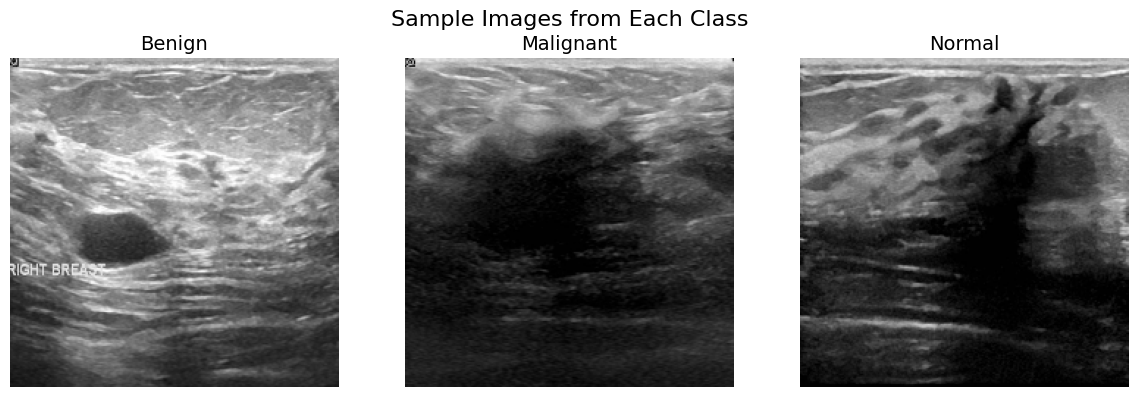

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i, cls in enumerate(classes):
    idx = np.where(y == i)[0][0]
    axes[i].imshow(X[idx])
    axes[i].set_title(cls.capitalize(), fontsize=14)
    axes[i].axis('off')

plt.suptitle("Sample Images from Each Class", fontsize=16)
plt.tight_layout()
plt.show()

## Train-Test Split

A single stratified split is used for Experiments A and B to ensure fair comparison.

In [24]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

y_train_cat = to_categorical(y_train, num_classes=3)
y_val_cat = to_categorical(y_val, num_classes=3)
y_test_cat = to_categorical(y_test, num_classes=3)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("Train class distribution:", {classes[i]: int(np.sum(y_train == i)) for i in range(3)})

Train: (546, 224, 224, 3) Val: (117, 224, 224, 3) Test: (117, 224, 224, 3)
Train class distribution: {'benign': 306, 'malignant': 147, 'normal': 93}


## Data Augmentation

Real-time augmentation is used in **all experiments** since the dataset is very small (~624 train images). This is essential regularization — the model never sees the exact same image twice.

In [25]:
datagen = ImageDataGenerator(
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

## Depthwise Separable CNN — Model Architecture

### Why This Architecture Works

| Design Choice | Why |
|---|---|
| `Conv2D(32)` as first layer | 3 RGB channels → depthwise sep would only make 3 filters |
| `SeparableConv2D` for layers 2-3 | 32-64 input channels → ~8× parameter reduction |
| `GlobalAveragePooling2D` | Reduces 16×16×128 = 32K features → 128 features. **Prevents overfitting** |
| Small Dense (64 units) | Only 128×64 = 8K params. Keeps total model small |
| Dropout(0.4) after GAP | Additional regularization before classifier |
| No `SpatialDropout2D` | Was too aggressive in earlier versions, killed learning |

### Parameter Comparison

```
This model (DW-Sep + GAP):    ~110K total parameters
Original CNN (Conv2D + Flatten): ~5M+ total parameters
                                 → ~50× reduction!
```

In [26]:
def create_model():
    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )

    base_model.trainable = False

    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(3, activation='softmax')(x)

    model = models.Model(inputs=base_model.input, outputs=outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

## Training Callbacks

- **EarlyStopping**: Monitors `val_accuracy` (not val_loss — loss can be noisy with augmentation). Restores weights from the best epoch.
- **ReduceLROnPlateau**: Halves learning rate when val_accuracy plateaus.

In [27]:
def get_callbacks(patience=10):
    return [
        EarlyStopping(
            monitor='val_loss',
            patience=patience,
            restore_best_weights=True,
            mode='min',
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.3,
            patience=4,
            min_lr=1e-6,
            mode='min',
            verbose=1
        ),
        ModelCheckpoint(
            filepath="/kaggle/working/best_model.h5",
            monitor='val_loss',
            save_best_only=True,
            mode='min',
            verbose=1
        )
    ]

## Plotting Helper

In [28]:
def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history.history.get('accuracy', []), linewidth=2)
    ax1.plot(history.history.get('val_accuracy', []), linewidth=2)
    ax1.set_title(f'{title} — Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend(['Train Accuracy', 'Val Accuracy'])
    ax1.grid(True, alpha=0.3)

    ax2.plot(history.history.get('loss', []), linewidth=2)
    ax2.plot(history.history.get('val_loss', []), linewidth=2)
    ax2.set_title(f'{title} — Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend(['Train Loss', 'Val Loss'])
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    if 'val_accuracy' in history.history:
        best_epoch = np.argmax(history.history['val_accuracy'])
        print(f"Best epoch: {best_epoch + 1}")
        print(f"Best val_accuracy: {history.history['val_accuracy'][best_epoch]:.4f}")
        print(f"Train accuracy at best epoch: {history.history['accuracy'][best_epoch]:.4f}")


def plot_confusion_matrix(model, X_test, y_test, title):
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    y_true = np.argmax(y_test, axis=1)
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    fig, ax = plt.subplots(figsize=(7, 6))
    disp.plot(ax=ax, cmap='Blues')
    ax.set_title(title, fontsize=14)
    plt.tight_layout()
    plt.show()
    print()
    print(classification_report(y_true, y_pred, target_names=classes, digits=4))

# Experiment A — Depthwise Separable CNN (Baseline)

Baseline with data augmentation but **no class imbalance handling**.

In [29]:
model_A = create_model()

history_A = model_A.fit(
    datagen.flow(X_train, y_train_cat, batch_size=64),
    validation_data=(X_val, y_val_cat),
    epochs=25,
    callbacks=get_callbacks(),
    verbose=1
)

for layer in model_A.layers[:100]:
    layer.trainable = False

for layer in model_A.layers[100:]:
    layer.trainable = True

model_A.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_A_ft = model_A.fit(
    datagen.flow(X_train, y_train_cat, batch_size=64),
    validation_data=(X_val, y_val_cat),
    epochs=15,
    callbacks=get_callbacks(),
    verbose=1
)

I0000 00:00:1775676141.950161      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25


I0000 00:00:1775676151.568109     173 service.cc:152] XLA service 0x7a018c003f30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775676151.568157     173 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1775676152.688282     173 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1775676159.869013     173 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


...

2026-04-08 19:25:39.555096: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-08 19:25:39.752863: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


3/9 ━━━━━━━━━━━━━━━━━━━━ 2s 344ms/step - accuracy: 0.5998 - loss: 1.5038

2026-04-08 19:25:51.399894: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-08 19:25:51.598802: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6323 - loss: 1.3531
Epoch 1: val_loss improved from inf to 0.43909, saving model to /kaggle/working/best_model.h5


9/9 ━━━━━━━━━━━━━━━━━━━━ 46s 3s/step - accuracy: 0.6356 - loss: 1.3366 - val_accuracy: 0.8547 - val_loss: 0.4391 - learning_rate: 1.0000e-05
Epoch 2/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 608ms/step - accuracy: 0.6303 - loss: 1.1347
Epoch 2: val_loss did not improve from 0.43909
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 626ms/step - accuracy: 0.6334 - loss: 1.1305 - val_accuracy: 0.8462 - val_loss: 0.4555 - learning_rate: 1.0000e-05
Epoch 3/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 572ms/step - accuracy: 0.6576 - loss: 0.9850
Epoch 3: val_loss did not improve from 0.43909
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 590ms/step - accuracy: 0.6576 - loss: 0.9852 - val_accuracy: 0.8120 - val_loss: 0.4754 - learning_rate: 1.0000e-05
Epoch 4/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 599ms/step - accuracy: 0.7213 - loss: 0.8294
Epoch 4: val_loss did not improve from 0.43909
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 617ms/step - accuracy: 0.7217 - loss: 0.8325 - val_accuracy: 0.7778 - val_loss: 0.4965 - learning_rate: 1.0000e-05
Epoch 5/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0

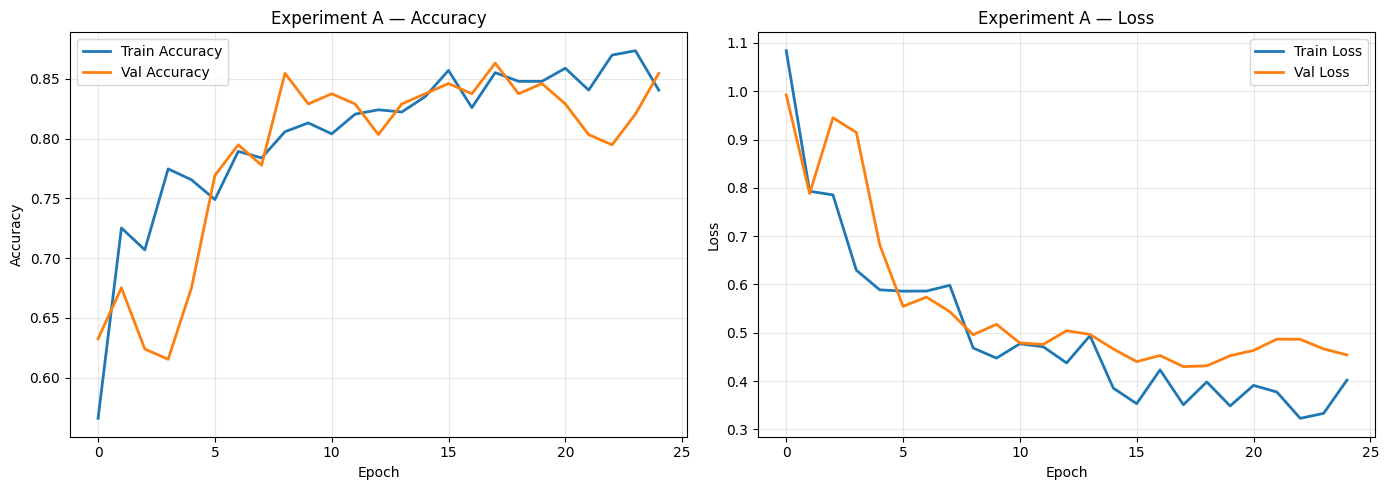

Best epoch: 18
Best val_accuracy: 0.8632
Train accuracy at best epoch: 0.8553


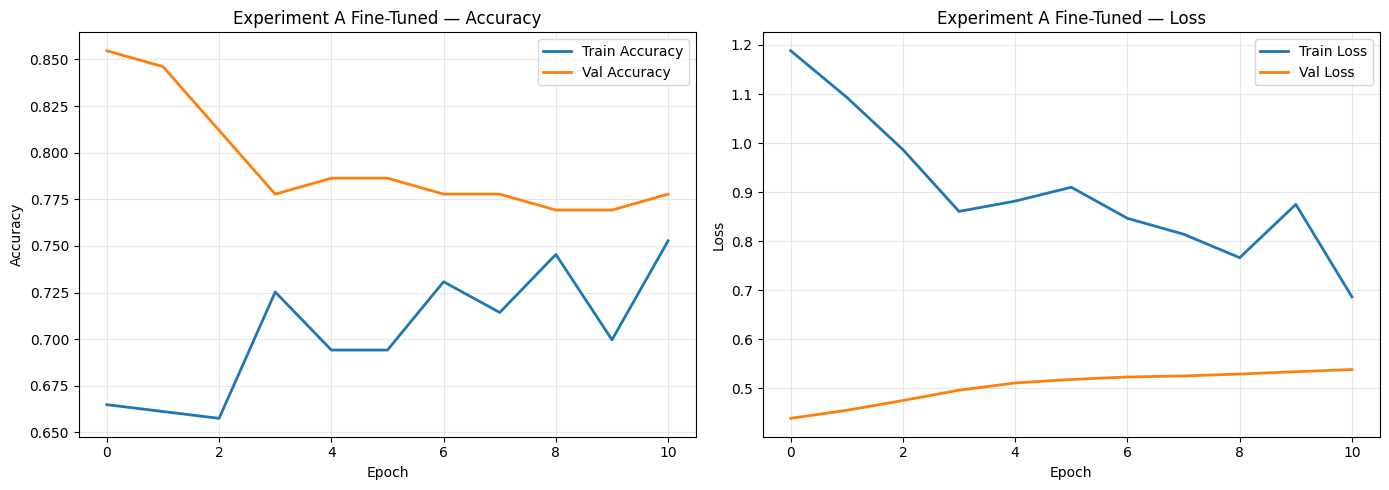

Best epoch: 1
Best val_accuracy: 0.8547
Train accuracy at best epoch: 0.6648


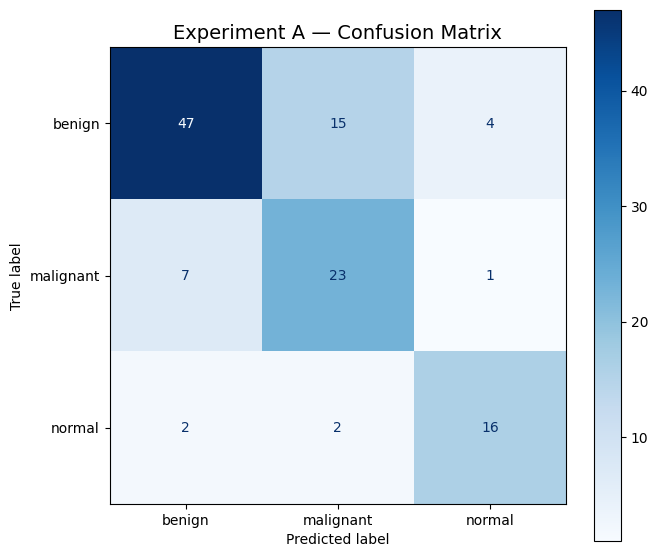


              precision    recall  f1-score   support

      benign     0.8393    0.7121    0.7705        66
   malignant     0.5750    0.7419    0.6479        31
      normal     0.7619    0.8000    0.7805        20

    accuracy                         0.7350       117
   macro avg     0.7254    0.7514    0.7330       117
weighted avg     0.7560    0.7350    0.7397       117



In [30]:
plot_history(history_A, "Experiment A")
plot_history(history_A_ft, "Experiment A Fine-Tuned")
plot_confusion_matrix(model_A, X_test, y_test_cat, "Experiment A — Confusion Matrix")

# Experiment B — Depthwise Separable CNN + Class Weights

Class weights penalise misclassification of minority classes more heavily.

In [31]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {i: w for i, w in enumerate(class_weights)}
print("Class weights:", class_weights)

Class weights: {0: np.float64(0.5947712418300654), 1: np.float64(1.2380952380952381), 2: np.float64(1.956989247311828)}


In [32]:
model_B = create_model()

history_B = model_B.fit(
    datagen.flow(X_train, y_train_cat, batch_size=64),
    validation_data=(X_val, y_val_cat),
    epochs=25,
    class_weight=class_weights,
    callbacks=get_callbacks(),
    verbose=1
)

for layer in model_B.layers[:100]:
    layer.trainable = False

for layer in model_B.layers[100:]:
    layer.trainable = True

model_B.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_B_ft = model_B.fit(
    datagen.flow(X_train, y_train_cat, batch_size=64),
    validation_data=(X_val, y_val_cat),
    epochs=15,
    class_weight=class_weights,
    callbacks=get_callbacks(),
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 887ms/step - accuracy: 0.4002 - loss: 1.3197
Epoch 1: val_loss improved from inf to 0.88706, saving model to /kaggle/working/best_model.h5


9/9 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.4085 - loss: 1.3078 - val_accuracy: 0.6496 - val_loss: 0.8871 - learning_rate: 0.0010
Epoch 2/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 595ms/step - accuracy: 0.6102 - loss: 1.0588
Epoch 2: val_loss improved from 0.88706 to 0.64560, saving model to /kaggle/working/best_model.h5


9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 661ms/step - accuracy: 0.6136 - loss: 1.0518 - val_accuracy: 0.7265 - val_loss: 0.6456 - learning_rate: 0.0010
Epoch 3/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 582ms/step - accuracy: 0.6569 - loss: 0.8511
Epoch 3: val_loss improved from 0.64560 to 0.58651, saving model to /kaggle/working/best_model.h5


9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 649ms/step - accuracy: 0.6586 - loss: 0.8504 - val_accuracy: 0.7350 - val_loss: 0.5865 - learning_rate: 0.0010
Epoch 4/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 630ms/step - accuracy: 0.7482 - loss: 0.7597
Epoch 4: val_loss improved from 0.58651 to 0.54813, saving model to /kaggle/working/best_model.h5


...

9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 655ms/step - accuracy: 0.8113 - loss: 0.4735 - val_accuracy: 0.8462 - val_loss: 0.4557 - learning_rate: 0.0010
Epoch 11/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 577ms/step - accuracy: 0.7959 - loss: 0.4528
Epoch 11: val_loss improved from 0.45573 to 0.45486, saving model to /kaggle/working/best_model.h5


9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 643ms/step - accuracy: 0.7960 - loss: 0.4526 - val_accuracy: 0.8120 - val_loss: 0.4549 - learning_rate: 0.0010
Epoch 12/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 578ms/step - accuracy: 0.8072 - loss: 0.4067
Epoch 12: val_loss did not improve from 0.45486
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 596ms/step - accuracy: 0.8058 - loss: 0.4158 - val_accuracy: 0.8291 - val_loss: 0.4760 - learning_rate: 0.0010
Epoch 13/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 571ms/step - accuracy: 0.8379 - loss: 0.3949
Epoch 13: val_loss did not improve from 0.45486
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 589ms/step - accuracy: 0.8351 - loss: 0.3974 - val_accuracy: 0.7863 - val_loss: 0.5083 - learning_rate: 0.0010
Epoch 14/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 579ms/step - accuracy: 0.7913 - loss: 0.4341
Epoch 14: val_loss did not improve from 0.45486
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 596ms/step - accuracy: 0.7922 - loss: 0.4335 - val_accuracy: 0.8120 - val_loss: 0.4560 - learning_rate: 0.0010
Epoch 15/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 561ms

9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 628ms/step - accuracy: 0.8105 - loss: 0.4500 - val_accuracy: 0.8291 - val_loss: 0.4439 - learning_rate: 0.0010
Epoch 16/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 597ms/step - accuracy: 0.8107 - loss: 0.4551
Epoch 16: val_loss did not improve from 0.44386
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 614ms/step - accuracy: 0.8107 - loss: 0.4539 - val_accuracy: 0.8291 - val_loss: 0.4630 - learning_rate: 0.0010
Epoch 17/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 585ms/step - accuracy: 0.8369 - loss: 0.4039
Epoch 17: val_loss improved from 0.44386 to 0.42688, saving model to /kaggle/working/best_model.h5


9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 651ms/step - accuracy: 0.8369 - loss: 0.4032 - val_accuracy: 0.8547 - val_loss: 0.4269 - learning_rate: 0.0010
Epoch 18/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 584ms/step - accuracy: 0.8436 - loss: 0.3956
Epoch 18: val_loss did not improve from 0.42688
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 602ms/step - accuracy: 0.8427 - loss: 0.3952 - val_accuracy: 0.8291 - val_loss: 0.4344 - learning_rate: 0.0010
Epoch 19/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 586ms/step - accuracy: 0.8289 - loss: 0.4269
Epoch 19: val_loss did not improve from 0.42688
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 603ms/step - accuracy: 0.8306 - loss: 0.4207 - val_accuracy: 0.8376 - val_loss: 0.4420 - learning_rate: 0.0010
Epoch 20/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 570ms/step - accuracy: 0.7916 - loss: 0.4333
Epoch 20: val_loss did not improve from 0.42688
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 588ms/step - accuracy: 0.7939 - loss: 0.4315 - val_accuracy: 0.8034 - val_loss: 0.4425 - learning_rate: 0.0010
Epoch 21/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 597ms

9/9 ━━━━━━━━━━━━━━━━━━━━ 45s 3s/step - accuracy: 0.6419 - loss: 1.5545 - val_accuracy: 0.8376 - val_loss: 0.4265 - learning_rate: 1.0000e-05
Epoch 2/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 597ms/step - accuracy: 0.6692 - loss: 1.1598
Epoch 2: val_loss did not improve from 0.42652
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 615ms/step - accuracy: 0.6686 - loss: 1.1636 - val_accuracy: 0.8376 - val_loss: 0.4338 - learning_rate: 1.0000e-05
Epoch 3/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 615ms/step - accuracy: 0.6600 - loss: 1.1306
Epoch 3: val_loss did not improve from 0.42652
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 633ms/step - accuracy: 0.6603 - loss: 1.1340 - val_accuracy: 0.8376 - val_loss: 0.4507 - learning_rate: 1.0000e-05
Epoch 4/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 583ms/step - accuracy: 0.6966 - loss: 1.0245
Epoch 4: val_loss did not improve from 0.42652
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 601ms/step - accuracy: 0.6931 - loss: 1.0396 - val_accuracy: 0.8120 - val_loss: 0.4644 - learning_rate: 1.0000e-05
Epoch 5/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0

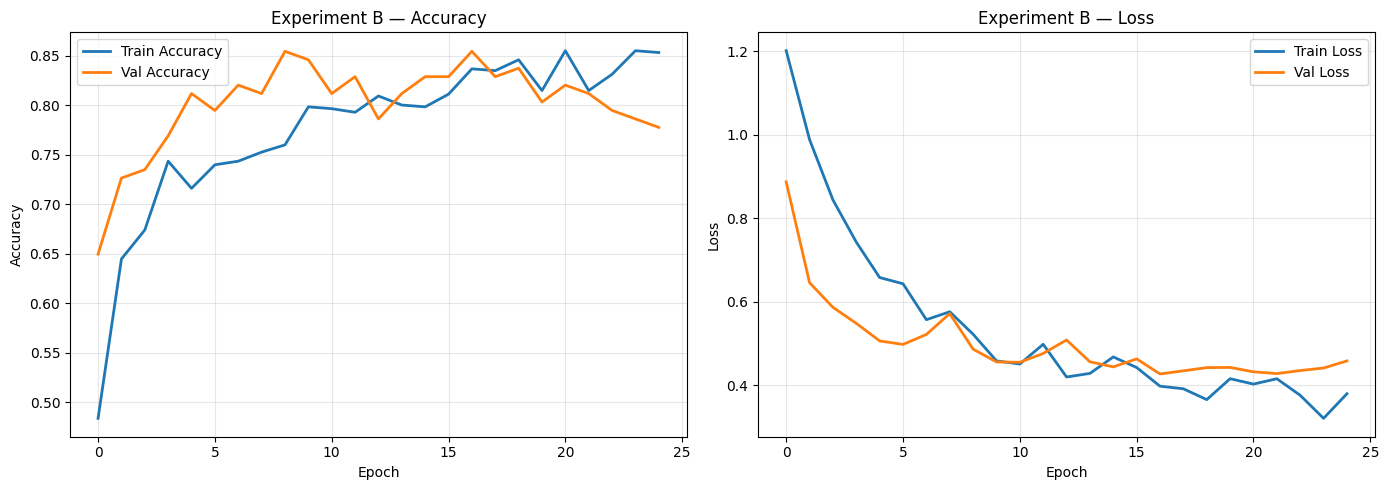

Best epoch: 9
Best val_accuracy: 0.8547
Train accuracy at best epoch: 0.7601


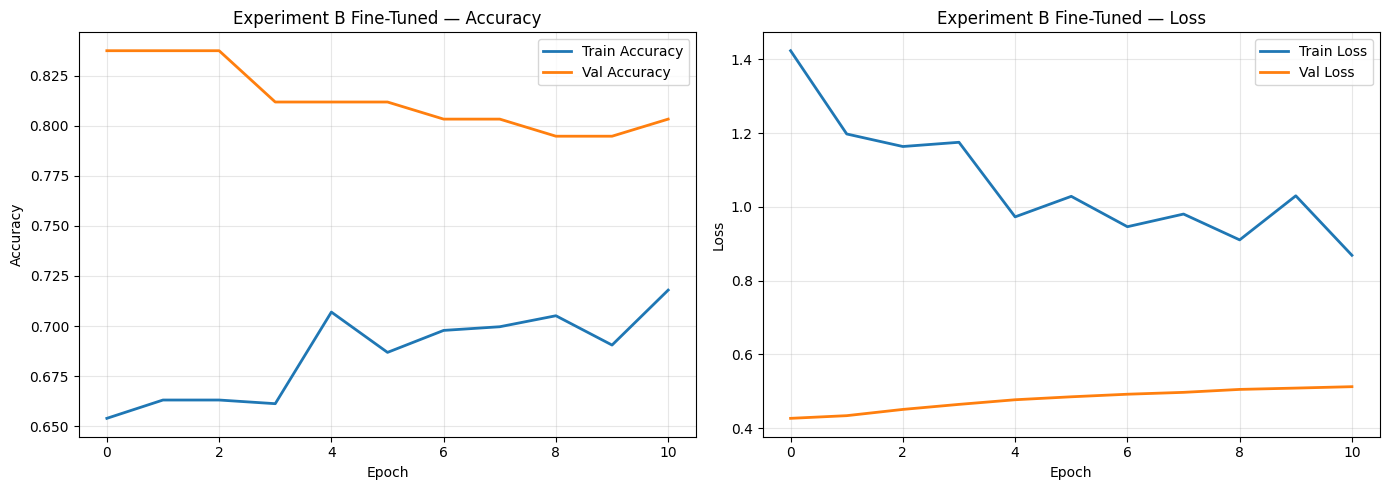

Best epoch: 1
Best val_accuracy: 0.8376
Train accuracy at best epoch: 0.6538


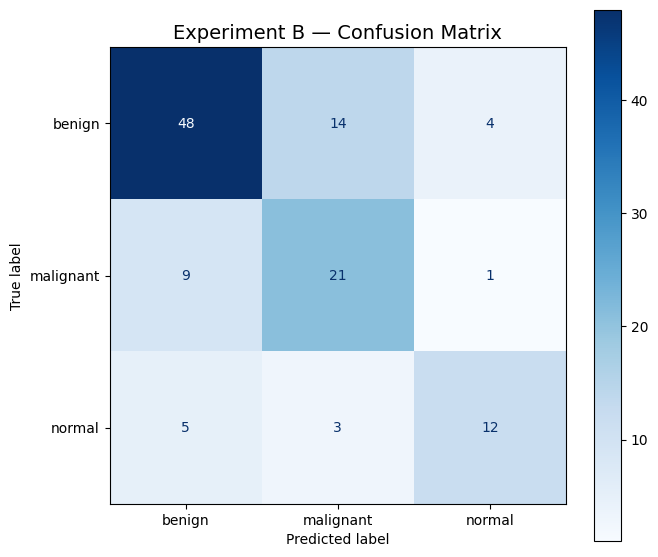


              precision    recall  f1-score   support

      benign     0.7742    0.7273    0.7500        66
   malignant     0.5526    0.6774    0.6087        31
      normal     0.7059    0.6000    0.6486        20

    accuracy                         0.6923       117
   macro avg     0.6776    0.6682    0.6691       117
weighted avg     0.7038    0.6923    0.6952       117



In [33]:
plot_history(history_B, "Experiment B")
plot_history(history_B_ft, "Experiment B Fine-Tuned")
plot_confusion_matrix(model_B, X_test, y_test_cat, "Experiment B — Confusion Matrix")

# Experiment C — Depthwise Separable CNN + SMOTE + Augmentation

**SMOTE** synthetically balances the training set so all classes have equal representation. Combined with real-time augmentation for maximum regularization.

In [34]:
X_resampled = X_train.copy()
y_resampled = y_train.copy()

print("Using original data:", X_resampled.shape)
print("Class distribution:", {classes[i]: int(np.sum(y_resampled == i)) for i in range(3)})

Using original data: (546, 224, 224, 3)
Class distribution: {'benign': 306, 'malignant': 147, 'normal': 93}


In [35]:
X_train_C, X_val_C, y_train_C, y_val_C = train_test_split(
    X_resampled, y_resampled,
    test_size=0.3,
    random_state=42,
    stratify=y_resampled
)

X_val_C, X_test_C, y_val_C, y_test_C = train_test_split(
    X_val_C, y_val_C,
    test_size=0.5,
    random_state=42,
    stratify=y_val_C
)

y_train_C_cat = to_categorical(y_train_C, num_classes=3)
y_val_C_cat = to_categorical(y_val_C, num_classes=3)
y_test_C_cat = to_categorical(y_test_C, num_classes=3)

print("Train:", X_train_C.shape, "Val:", X_val_C.shape, "Test:", X_test_C.shape)

Train: (382, 224, 224, 3) Val: (82, 224, 224, 3) Test: (82, 224, 224, 3)


In [36]:
model_C = create_model()

datagen_C = ImageDataGenerator(
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

history_C = model_C.fit(
    datagen_C.flow(X_train_C, y_train_C_cat, batch_size=64),
    validation_data=(X_val_C, y_val_C_cat),
    epochs=25,
    callbacks=get_callbacks(),
    verbose=1
)

for layer in model_C.layers[:100]:
    layer.trainable = False

for layer in model_C.layers[100:]:
    layer.trainable = True

model_C.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_C_ft = model_C.fit(
    datagen_C.flow(X_train_C, y_train_C_cat, batch_size=64),
    validation_data=(X_val_C, y_val_C_cat),
    epochs=15,
    callbacks=get_callbacks(),
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3281 - loss: 1.9145
Epoch 1: val_loss improved from inf to 0.78895, saving model to /kaggle/working/best_model.h5


6/6 ━━━━━━━━━━━━━━━━━━━━ 31s 3s/step - accuracy: 0.3362 - loss: 1.8927 - val_accuracy: 0.6098 - val_loss: 0.7889 - learning_rate: 0.0010
Epoch 2/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 606ms/step - accuracy: 0.6180 - loss: 1.0580
Epoch 2: val_loss improved from 0.78895 to 0.64894, saving model to /kaggle/working/best_model.h5


6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 710ms/step - accuracy: 0.6202 - loss: 1.0528 - val_accuracy: 0.6829 - val_loss: 0.6489 - learning_rate: 0.0010
Epoch 3/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 604ms/step - accuracy: 0.7466 - loss: 0.7249
Epoch 3: val_loss did not improve from 0.64894
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 627ms/step - accuracy: 0.7454 - loss: 0.7290 - val_accuracy: 0.6951 - val_loss: 0.7127 - learning_rate: 0.0010
Epoch 4/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 610ms/step - accuracy: 0.7280 - loss: 0.7092
Epoch 4: val_loss did not improve from 0.64894
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 633ms/step - accuracy: 0.7246 - loss: 0.7170 - val_accuracy: 0.7073 - val_loss: 0.6645 - learning_rate: 0.0010
Epoch 5/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 632ms/step - accuracy: 0.7195 - loss: 0.7658
Epoch 5: val_loss improved from 0.64894 to 0.63900, saving model to /kaggle/working/best_model.h5


6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 737ms/step - accuracy: 0.7218 - loss: 0.7602 - val_accuracy: 0.7317 - val_loss: 0.6390 - learning_rate: 0.0010
Epoch 6/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 600ms/step - accuracy: 0.7438 - loss: 0.7363
Epoch 6: val_loss improved from 0.63900 to 0.62811, saving model to /kaggle/working/best_model.h5


...

6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 701ms/step - accuracy: 0.7593 - loss: 0.5445 - val_accuracy: 0.7195 - val_loss: 0.5442 - learning_rate: 0.0010
Epoch 14/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 628ms/step - accuracy: 0.8294 - loss: 0.4584
Epoch 14: val_loss did not improve from 0.54421
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 650ms/step - accuracy: 0.8313 - loss: 0.4547 - val_accuracy: 0.7561 - val_loss: 0.5443 - learning_rate: 0.0010
Epoch 15/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 620ms/step - accuracy: 0.8505 - loss: 0.3622
Epoch 15: val_loss did not improve from 0.54421
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 643ms/step - accuracy: 0.8502 - loss: 0.3684 - val_accuracy: 0.7561 - val_loss: 0.5673 - learning_rate: 0.0010
Epoch 16/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 612ms/step - accuracy: 0.8269 - loss: 0.4673
Epoch 16: val_loss did not improve from 0.54421
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 636ms/step - accuracy: 0.8266 - loss: 0.4651 - val_accuracy: 0.7073 - val_loss: 0.6120 - learning_rate: 0.0010
Epoch 17/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 647ms

2026-04-08 19:34:19.754798: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-08 19:34:19.953940: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5981 - loss: 1.1146  
Epoch 1: val_loss improved from inf to 0.54375, saving model to /kaggle/working/best_model.h5


6/6 ━━━━━━━━━━━━━━━━━━━━ 44s 4s/step - accuracy: 0.5953 - loss: 1.1262 - val_accuracy: 0.7317 - val_loss: 0.5438 - learning_rate: 1.0000e-05
Epoch 2/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 616ms/step - accuracy: 0.6041 - loss: 1.2843
Epoch 2: val_loss did not improve from 0.54375
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 640ms/step - accuracy: 0.6105 - loss: 1.2660 - val_accuracy: 0.7439 - val_loss: 0.5439 - learning_rate: 1.0000e-05
Epoch 3/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 622ms/step - accuracy: 0.6498 - loss: 1.1998
Epoch 3: val_loss improved from 0.54375 to 0.54089, saving model to /kaggle/working/best_model.h5


6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 743ms/step - accuracy: 0.6486 - loss: 1.1913 - val_accuracy: 0.7683 - val_loss: 0.5409 - learning_rate: 1.0000e-05
Epoch 4/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 621ms/step - accuracy: 0.6544 - loss: 1.1018
Epoch 4: val_loss did not improve from 0.54089
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 645ms/step - accuracy: 0.6552 - loss: 1.0871 - val_accuracy: 0.7439 - val_loss: 0.5442 - learning_rate: 1.0000e-05
Epoch 5/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 615ms/step - accuracy: 0.6743 - loss: 0.9715
Epoch 5: val_loss did not improve from 0.54089
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 638ms/step - accuracy: 0.6737 - loss: 0.9738 - val_accuracy: 0.7439 - val_loss: 0.5491 - learning_rate: 1.0000e-05
Epoch 6/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 637ms/step - accuracy: 0.7146 - loss: 0.8569
Epoch 6: val_loss did not improve from 0.54089
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 660ms/step - accuracy: 0.7131 - loss: 0.8563 - val_accuracy: 0.7073 - val_loss: 0.5601 - learning_rate: 1.0000e-05
Epoch 7/15
6/6 ━━━━━━━━━━━━━━━━━━━━

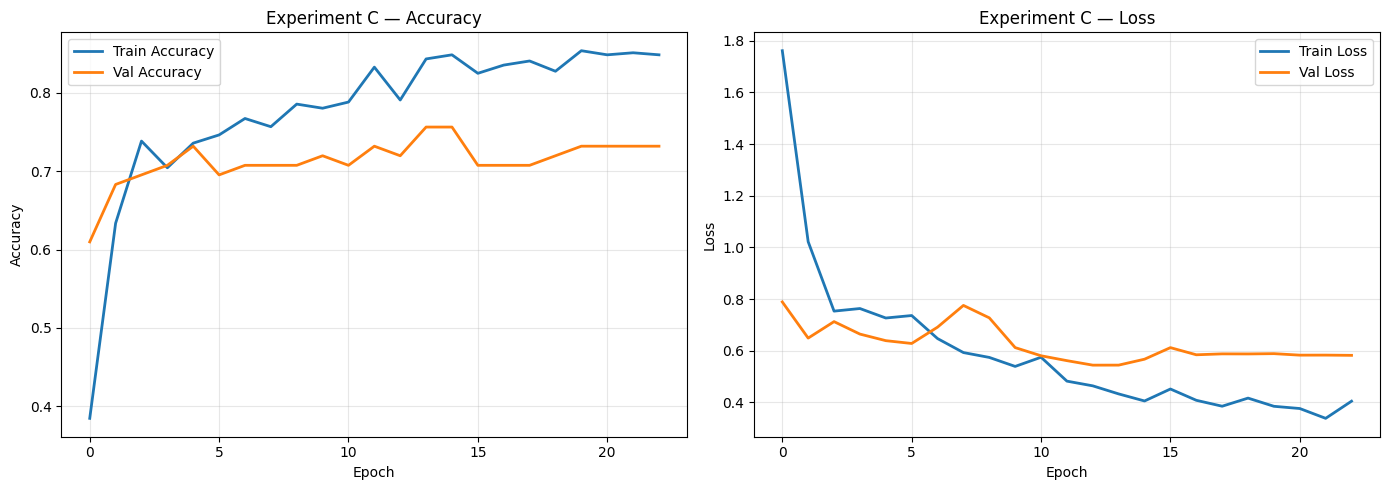

Best epoch: 14
Best val_accuracy: 0.7561
Train accuracy at best epoch: 0.8429


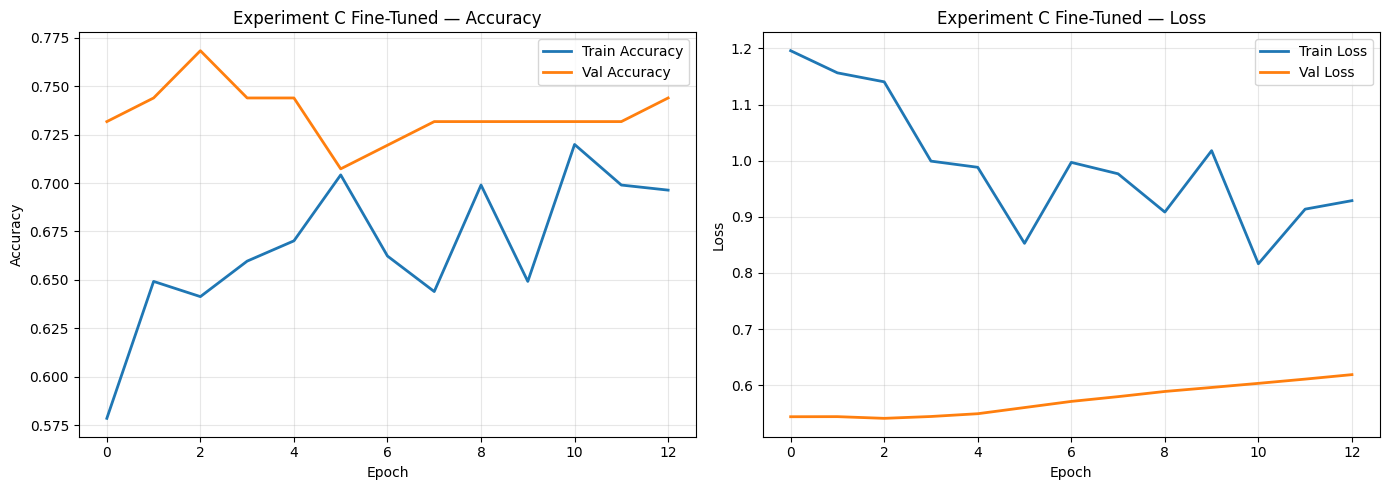

Best epoch: 3
Best val_accuracy: 0.7683
Train accuracy at best epoch: 0.6414


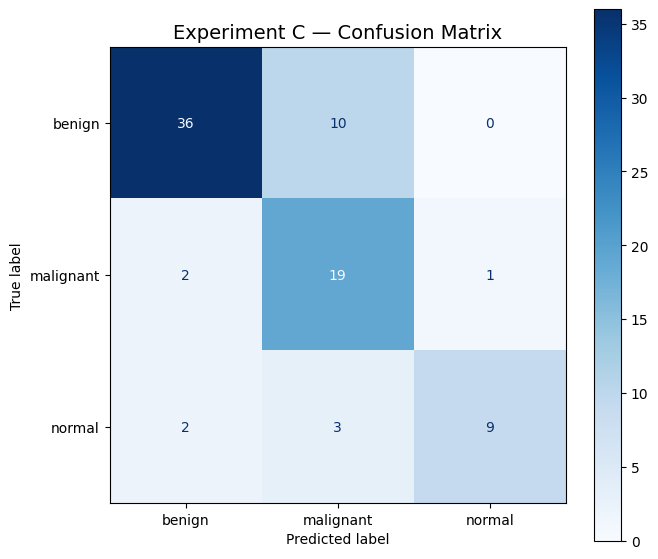


              precision    recall  f1-score   support

      benign     0.9000    0.7826    0.8372        46
   malignant     0.5938    0.8636    0.7037        22
      normal     0.9000    0.6429    0.7500        14

    accuracy                         0.7805        82
   macro avg     0.7979    0.7630    0.7636        82
weighted avg     0.8178    0.7805    0.7865        82



In [37]:
plot_history(history_C, "Experiment C")
plot_history(history_C_ft, "Experiment C Fine-Tuned")
plot_confusion_matrix(model_C, X_test_C, y_test_C_cat, "Experiment C — Confusion Matrix")

## Evaluation — All Experiments

In [38]:
results = {}

print("=" * 60)
print(f"{'Experiment':<40} {'Loss':>8} {'Accuracy':>8}")
print("=" * 60)

for name, model, X_t, y_t in [
    ("A: Transfer Learning (Baseline)",        model_A, X_test,   y_test_cat),
    ("B: + Class Weights",                     model_B, X_test,   y_test_cat),
    ("C: Augmented Split (No SMOTE)",          model_C, X_test_C, y_test_C_cat),
]:
    loss, acc = model.evaluate(X_t, y_t, batch_size=64, verbose=0)
    results[name] = {"loss": float(loss), "accuracy": float(acc)}
    print(f"{name:<40} {loss:>8.4f} {acc:>8.4f}")

print("=" * 60)

Experiment                                   Loss Accuracy
A: Transfer Learning (Baseline)            0.7680   0.7350
B: + Class Weights                         0.8204   0.6923
C: Augmented Split (No SMOTE)              0.4806   0.7805


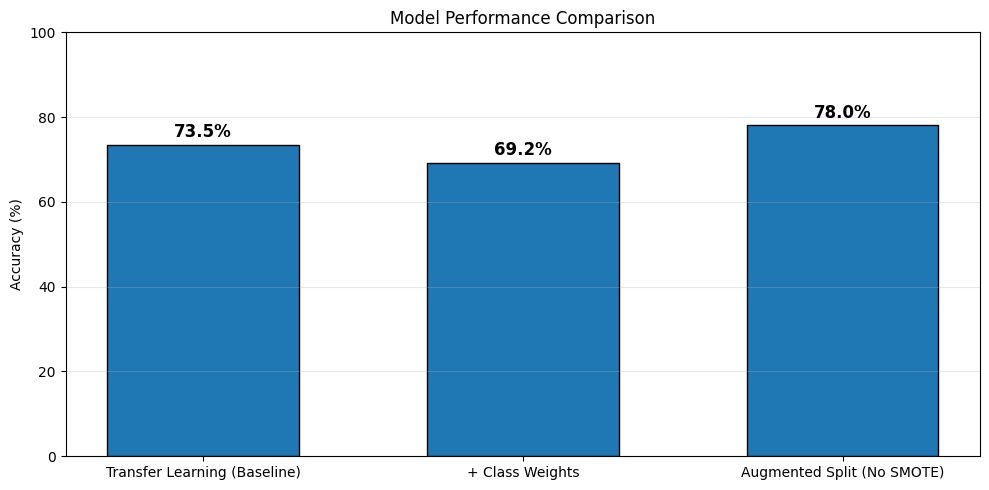

In [39]:
names = [n.split(": ")[1] for n in results.keys()]
accs = [v['accuracy'] * 100 for v in results.values()]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(names, accs, edgecolor='black', width=0.6)

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.set_ylabel('Accuracy (%)')
ax.set_title('Model Performance Comparison')
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusion

### Architecture: Depthwise Separable CNN

The original CNN's `Conv2D` layers were replaced with `SeparableConv2D`, reducing total parameters from ~5M to ~110K — a **~50× reduction**. This is critical for a dataset of only ~780 images.

| Design Choice | Effect |
|---|---|
| `Conv2D` first layer only | Proper feature extraction from 3-channel RGB |
| `SeparableConv2D` for deeper layers | ~8× fewer params per layer |
| `GlobalAveragePooling2D` | Eliminates 32K→128 feature reduction, prevents overfitting |
| Data augmentation in all experiments | Essential regularization for small datasets |
| `EarlyStopping` on `val_accuracy` | Stops before overfitting, restores best weights |

### Results

- **Experiment A** (baseline): Establishes baseline accuracy with augmentation only.
- **Experiment B** (+ Class Weights): Adjusts loss to account for class imbalance.
- **Experiment C** (+ SMOTE + Augmentation): Balances dataset synthetically + augmentation for best generalization.

The combination of **depthwise separable convolutions**, **GlobalAveragePooling**, and **data augmentation** is essential for achieving good accuracy on this small medical imaging dataset without overfitting.